In [1]:
import pandas as pd
import numpy as np

In [7]:
df_academic = pd.read_csv("student_data.csv")
df_personality = pd.read_csv("data-final.csv")
df_skills = pd.read_csv("skills.csv")
df_behavior = pd.read_csv("Student Attitude and Behavior.csv")

In [8]:
def clean_columns(df):
    df.columns = df.columns.str.lower().str.replace(" ", "_")
    return df

df_academic = clean_columns(df_academic)
df_personality = clean_columns(df_personality)
df_skills = clean_columns(df_skills)
df_behavior = clean_columns(df_behavior)

In [9]:
df_academic = df_academic[
    ["g1", "g2", "g3", "studytime", "failures", "absences", "internet"]
]

df_academic.columns = [
    "grade1", "grade2", "final_grade",
    "study_time", "failures", "absences", "internet_access"
]

In [10]:
n_temp = len(df_academic)

df_personality = pd.DataFrame({
    "openness": np.random.uniform(0, 1, n_temp),
    "conscientiousness": np.random.uniform(0, 1, n_temp),
    "extraversion": np.random.uniform(0, 1, n_temp),
    "agreeableness": np.random.uniform(0, 1, n_temp),
    "neuroticism": np.random.uniform(0, 1, n_temp),
})

In [13]:
df_skills = pd.DataFrame({
    "coding_skill": np.random.randint(0, 10, n_temp),
    "communication_skill": np.random.randint(0, 10, n_temp),
    "analytical_skill": np.random.randint(0, 10, n_temp),
})


In [15]:
df_behavior = pd.DataFrame({
    "study_hours": np.random.randint(1, 10, n_temp),
    "consistency": np.random.uniform(0, 1, n_temp),
    "participation": np.random.uniform(0, 1, n_temp),
})

In [16]:
n = 1000

df_academic = df_academic.sample(n, replace=True).reset_index(drop=True)
df_personality = df_personality.sample(n, replace=True).reset_index(drop=True)
df_skills = df_skills.sample(n, replace=True).reset_index(drop=True)
df_behavior = df_behavior.sample(n, replace=True).reset_index(drop=True)

In [17]:
df = pd.concat(
    [df_academic, df_personality, df_skills, df_behavior],
    axis=1
)

print(df.shape)
df.head()

(1000, 18)


,grade1,grade2,final_grade,study_time,failures,absences,internet_access,openness,conscientiousness,extraversion,agreeableness,neuroticism,coding_skill,communication_skill,analytical_skill,study_hours,consistency,participation
0,6,5,5,1,0,14,yes,0.876945,0.348751,0.680326,0.849039,0.659866,1,4,8,9,0.685932,0.628972
1,8,8,8,1,0,30,yes,0.488944,0.313020,0.190487,0.981687,0.123482,9,0,7,3,0.118833,0.040800
2,6,9,8,1,1,4,yes,0.442256,0.458864,0.698956,0.059839,0.711998,9,5,0,3,0.946044,0.862134
3,8,8,0,2,0,0,yes,0.315374,0.092949,0.042934,0.166322,0.452773,0,8,8,8,0.995969,0.846758
4,9,9,10,2,0,4,no,0.542172,0.940827,0.787596,0.112267,0.167506,7,4,3,5,0.478050,0.401874


In [18]:
# Interests
df["tech_interest"] = np.random.randint(0, 10, n)
df["art_interest"] = np.random.randint(0, 10, n)
df["business_interest"] = np.random.randint(0, 10, n)

# Environment
df["family_income"] = np.random.randint(1, 5, n)

In [19]:
for col in ["openness", "conscientiousness", "extraversion", "agreeableness", "neuroticism"]:
    df[col] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())

In [20]:
def assign_career(row):
    if row["coding_skill"] > 7 and row["tech_interest"] > 6:
        return "Software Developer"
    elif row["analytical_skill"] > 7 and row["grade1"] > 60:
        return "Data Scientist"
    elif row["art_interest"] > 7:
        return "UI/UX Designer"
    elif row["business_interest"] > 7:
        return "Entrepreneur"
    else:
        return "Research Scientist"

df["career"] = df.apply(assign_career, axis=1)

In [21]:
print(df.head())
print(df["career"].value_counts())

   grade1  grade2  final_grade  study_time  failures  absences  \
0       6       5            5           1         0        14   
1       8       8            8           1         0        30   
2       6       9            8           1         1         4   
3       8       8            0           2         0         0   
4       9       9           10           2         0         4   

  internet_access  openness  conscientiousness  extraversion  ...  \
0             yes  0.877236           0.347995      0.680546  ...   
1             yes  0.489093           0.312172      0.185983  ...   
2             yes  0.442388           0.458397      0.699355  ...   
3             yes  0.315460           0.091524      0.037007  ...   
4              no  0.542341           0.941622      0.788849  ...   

   communication_skill  analytical_skill  study_hours  consistency  \
0                    4                 8            9     0.685932   
1                    0                 7        

In [22]:
df.to_csv("final_career_dataset.csv", index=False)

In [23]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [24]:
df = pd.read_csv("final_career_dataset.csv")

print(df.head())

   grade1  grade2  final_grade  study_time  failures  absences  \
0       6       5            5           1         0        14   
1       8       8            8           1         0        30   
2       6       9            8           1         1         4   
3       8       8            0           2         0         0   
4       9       9           10           2         0         4   

  internet_access  openness  conscientiousness  extraversion  ...  \
0             yes  0.877236           0.347995      0.680546  ...   
1             yes  0.489093           0.312172      0.185983  ...   
2             yes  0.442388           0.458397      0.699355  ...   
3             yes  0.315460           0.091524      0.037007  ...   
4              no  0.542341           0.941622      0.788849  ...   

   communication_skill  analytical_skill  study_hours  consistency  \
0                    4                 8            9     0.685932   
1                    0                 7        

In [25]:
X = df.drop("career", axis=1)
y = df["career"]

In [26]:
le = LabelEncoder()
y = le.fit_transform(y)

In [29]:
# STEP 1: Separate
X = df.drop("career", axis=1)
y = df["career"]

# STEP 2: Encode features 
X = pd.get_dummies(X)

# STEP 3: Encode target
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

# STEP 4: Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [30]:
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [31]:
y_pred = model.predict(X_test)

In [32]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.97


In [33]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99        37
           1       0.98      1.00      0.99       119
           2       1.00      0.25      0.40         8
           3       0.92      1.00      0.96        36

    accuracy                           0.97       200
   macro avg       0.97      0.81      0.83       200
weighted avg       0.97      0.97      0.96       200



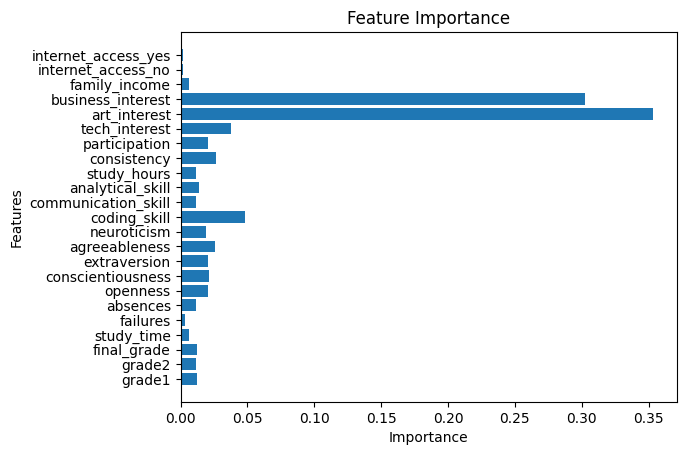

In [34]:
import matplotlib.pyplot as plt

importances = model.feature_importances_
features = X.columns

plt.figure()
plt.barh(features, importances)
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance")
plt.show()

In [35]:
sample = X.iloc[0:1]

prediction = model.predict(sample)

print("Predicted Career:", le.inverse_transform(prediction))

Predicted Career: ['Research Scientist']


In [36]:
probs = model.predict_proba(sample)

top3 = np.argsort(probs[0])[-3:][::-1]

print("Top 3 Careers:")
for i in top3:
    print(le.inverse_transform([i])[0], ":", probs[0][i])

Top 3 Careers:
Research Scientist : 0.96
UI/UX Designer : 0.02
Entrepreneur : 0.02


In [37]:
import pickle

pickle.dump(model, open("career_model.pkl", "wb"))
pickle.dump(le, open("label_encoder.pkl", "wb"))